# A. Data Preprocessing

## Import Libraries

In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from statsmodels.stats.contingency_tables import mcnemar


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Load and explore the dataset

In [4]:
df = pd.read_csv(
    "C:\\Users\\efgab\\OneDrive\\Desktop\\Instant\\Ensemble_Learning\\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [9]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## Handle Missing Values


In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [13]:
df = df.drop("customerID", axis=1)

KeyError: "['customerID'] not found in axis"

## Target

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [17]:
y = y.map({
    "No": 0,
    "Yes": 1
})

## Check Class Imbalance

In [18]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## Split data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1765,
    random_state=42,
    stratify=y_train
)

In [21]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [22]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [23]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [25]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)


# B. Individual Base Models 

## Decision Tree

In [27]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [28]:
dt_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [29]:
dt_val_pred = dt_model.predict(X_val_processed)

In [30]:
dt_accuracy = accuracy_score(y_val, dt_val_pred)
dt_precision = precision_score(y_val, dt_val_pred)
dt_recall = recall_score(y_val, dt_val_pred)
dt_f1 = f1_score(y_val, dt_val_pred)

In [31]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_val, dt_val_pred))
print("Precision:", precision_score(y_val, dt_val_pred))
print("Recall   :", recall_score(y_val, dt_val_pred))
print("F1 Score :", f1_score(y_val, dt_val_pred))

Decision Tree
Accuracy : 0.7218543046357616
Precision: 0.47735191637630664
Recall   : 0.4875444839857651
F1 Score : 0.4823943661971831


## Logistic Regression

In [32]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [33]:
lr_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [34]:
lr_val_pred = lr_model.predict(X_val_processed)

In [35]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_val, lr_val_pred))
print("Precision:", precision_score(y_val, lr_val_pred))
print("Recall   :", recall_score(y_val, lr_val_pred))
print("F1 Score :", f1_score(y_val, lr_val_pred))

Logistic Regression
Accuracy : 0.7426679280983917
Precision: 0.5106382978723404
Recall   : 0.7686832740213523
F1 Score : 0.6136363636363636


## Support Vector Machine

In [36]:
svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42
)

In [37]:
svm_model.fit(
    X_train_processed,
    y_train
)

c:\Users\efgab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [38]:
svm_val_pred = svm_model.predict(X_val_processed)

In [39]:
print("Support Vector Machine")
print("Accuracy :", accuracy_score(y_val, svm_val_pred))
print("Precision:", precision_score(y_val, svm_val_pred))
print("Recall   :", recall_score(y_val, svm_val_pred))
print("F1 Score :", f1_score(y_val, svm_val_pred))

Support Vector Machine
Accuracy : 0.7407757805108799
Precision: 0.5083532219570406
Recall   : 0.7580071174377224
F1 Score : 0.6085714285714285


# C. Ensemble Methods Implementation

## Bagging

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [41]:
rf_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [42]:
rf_val_pred = rf_model.predict(X_val_processed)

In [43]:
rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_precision = precision_score(y_val, rf_val_pred)
rf_recall = recall_score(y_val, rf_val_pred)
rf_f1 = f1_score(y_val, rf_val_pred)

In [44]:
print("\nRandom Forest")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")


Random Forest
Accuracy : 0.7890
Precision: 0.5948
Recall   : 0.6477
F1 Score : 0.6201


In [45]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1 Score": [dt_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.721854,0.477352,0.487544,0.482394
1,Random Forest,0.789026,0.594771,0.647687,0.620102


## Boosting

### Gradient Boosting: Learning Step by Step

Gradient Boosting builds small trees one after another. Each new tree tries to fix some mistakes from the earlier trees. Random Forest builds its trees separately, but Gradient Boosting builds them step by step.


In [46]:
gb_model = GradientBoostingClassifier(
    n_estimators=1800,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

In [47]:
gb_model.fit(X_train_processed, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1800
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

In [48]:
gb_val_pred = gb_model.predict(X_val_processed)

In [49]:
gb_accuracy = accuracy_score(y_val, gb_val_pred)
gb_precision = precision_score(y_val, gb_val_pred)
gb_recall = recall_score(y_val, gb_val_pred)
gb_f1 = f1_score(y_val, gb_val_pred)

In [50]:
print("Gradient Boosting")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")

Gradient Boosting
Accuracy : 0.7985
Precision: 0.6478
Recall   : 0.5302
F1 Score : 0.5832


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1,
        gb_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.721854,0.477352,0.487544,0.482394
1,Random Forest,0.789026,0.594771,0.647687,0.620102
2,Gradient Boosting,0.798486,0.647826,0.530249,0.583170


In [52]:
train_scores = []
val_scores = []

for train_pred, val_pred in zip(
    gb_model.staged_predict(X_train_processed),
    gb_model.staged_predict(X_val_processed)
):
    train_scores.append(accuracy_score(y_train, train_pred))
    val_scores.append(accuracy_score(y_val, val_pred))

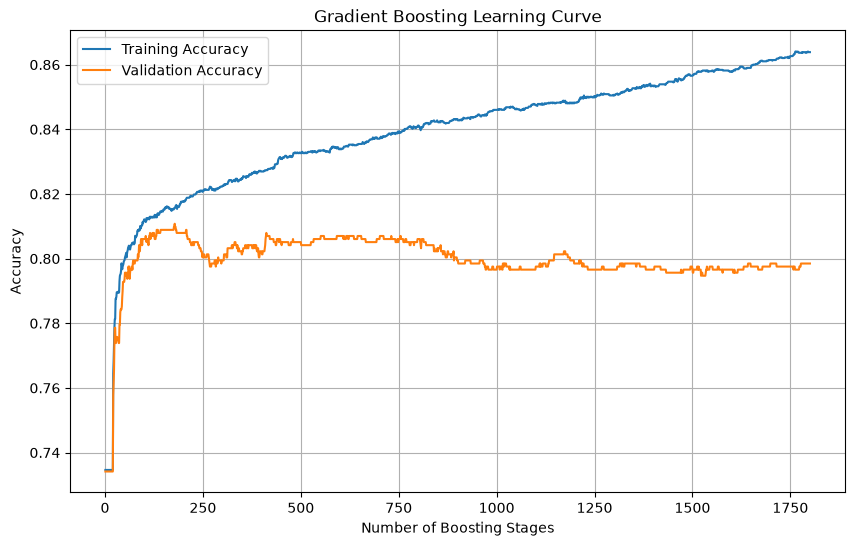

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_scores) + 1),
    train_scores,
    label="Training Accuracy"
)

plt.plot(
    range(1, len(val_scores) + 1),
    val_scores,
    label="Validation Accuracy"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

## Stacking

In [54]:
base_learners = [
    ("logistic_regression", lr_model),
    ("svm", svm_model),
    ("random_forest", rf_model)
]

In [55]:
# Meta-Learner
meta_learner = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

In [56]:
stacking_model.fit(X_train_processed, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logistic_regression', ...), ('svm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[LogisticRegre...ndom_state=42), SVC(class_wei...ndom_state=42), RandomForestC...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...ndom_state=42)


### How Stacking Works

Stacking uses several models first, then one final model makes the prediction.

```text
                    Training Data
                         |
          +--------------+--------------+
          |              |              |
          v              v              v
   Logistic Regression   SVM      Random Forest
          |              |              |
          +--------------+--------------+
                         |
                 Base Predictions
                         |
                         v
                 Meta-Learner
              Logistic Regression
                         |
                         v
                  Final Prediction
```

The first models are different: Logistic Regression is a simple linear model, SVM separates the classes in another way, and Random Forest uses many trees. The final Logistic Regression model learns how to use their predictions.


In [57]:
stacking_val_pred = stacking_model.predict(X_val_processed)

In [58]:
print("Stacking Classifier")
print(f"Accuracy : {accuracy_score(y_val, stacking_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, stacking_val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, stacking_val_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, stacking_val_pred):.4f}")

Stacking Classifier
Accuracy : 0.7521
Precision: 0.5227
Recall   : 0.7794
F1 Score : 0.6257


# D. Model Evaluation & Comparison

In [59]:
models_to_compare = {
    "Decision Tree": dt_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "Stacking": stacking_model
}

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [61]:
results = []
trained_models = {}

for model_name, model in models_to_compare.items():
    current_model = clone(model)

    start_time = time.time()
    current_model.fit(X_train_processed, y_train)
    training_time = time.time() - start_time

    y_pred = current_model.predict(X_val_processed)
    y_prob = current_model.predict_proba(X_val_processed)[:, 1]

    cv_scores = cross_validate(
        clone(model),
        X_train_processed,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1"
        },
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "Training Time (sec)": training_time,
        "CV Accuracy Mean": cv_scores["test_accuracy"].mean(),
        "CV F1 Mean": cv_scores["test_f1"].mean(),
        "CV F1 Std": cv_scores["test_f1"].std()
    })

    trained_models[model_name] = current_model

comparison_df = pd.DataFrame(results).sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df

c:\Users\efgab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec),CV Accuracy Mean,CV F1 Mean,CV F1 Std
0,Stacking,0.752129,0.522673,0.779359,0.625714,0.831676,17.511889,0.752892,0.631656,0.009572
1,Random Forest,0.789026,0.594771,0.647687,0.620102,0.818375,0.965013,0.775817,0.602426,0.015095
2,Logistic Regression,0.742668,0.510638,0.768683,0.613636,0.829223,0.067396,0.752689,0.634777,0.009576
3,SVM,0.740776,0.508353,0.758007,0.608571,0.817256,8.523146,0.743964,0.619414,0.011079
4,Gradient Boosting,0.798486,0.647826,0.530249,0.583170,0.832261,20.659440,0.793062,0.570935,0.014528
5,Decision Tree,0.721854,0.477352,0.487544,0.482394,0.646405,0.104904,0.739099,0.506802,0.014910


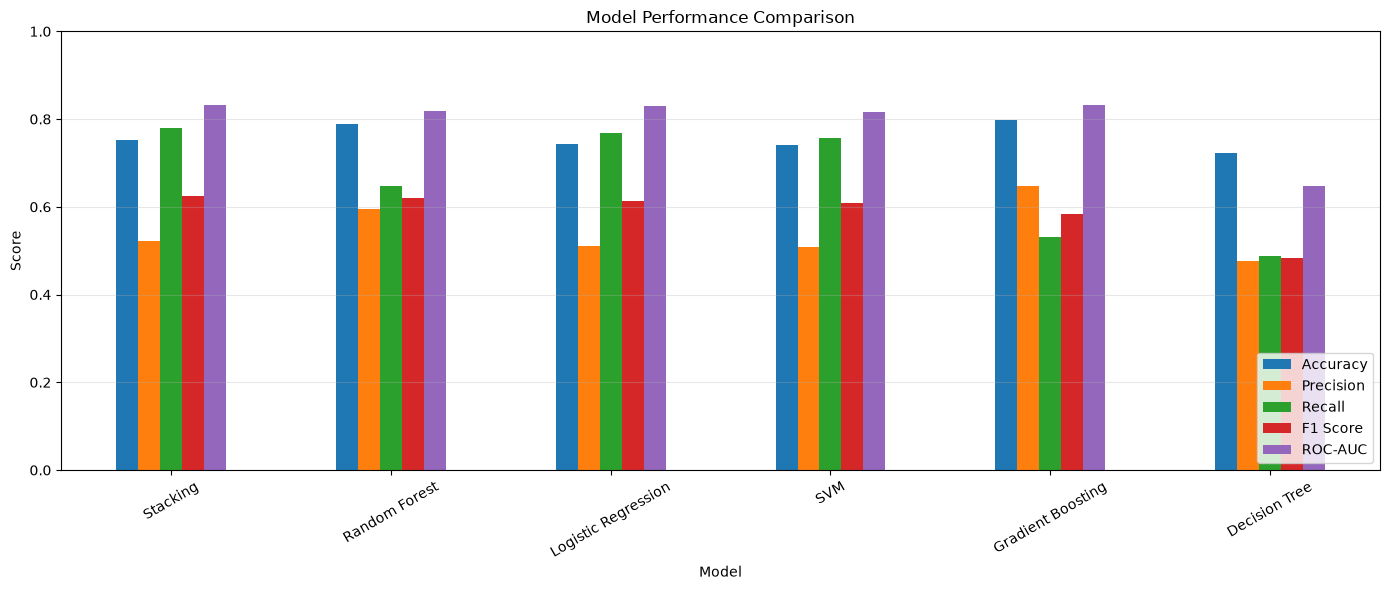

In [62]:
plot_columns = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison_df.set_index("Model")[plot_columns].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

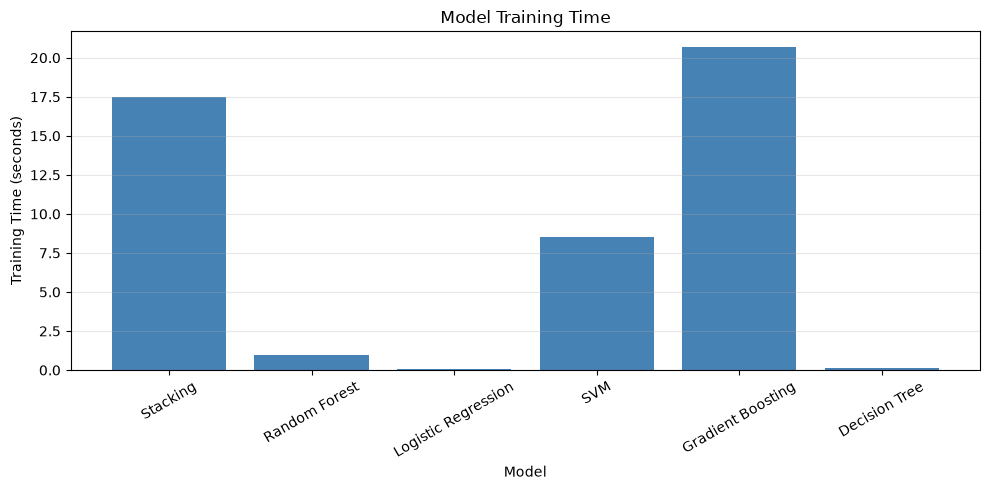

In [63]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (sec)"],
    color="steelblue"
)

plt.title("Model Training Time")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

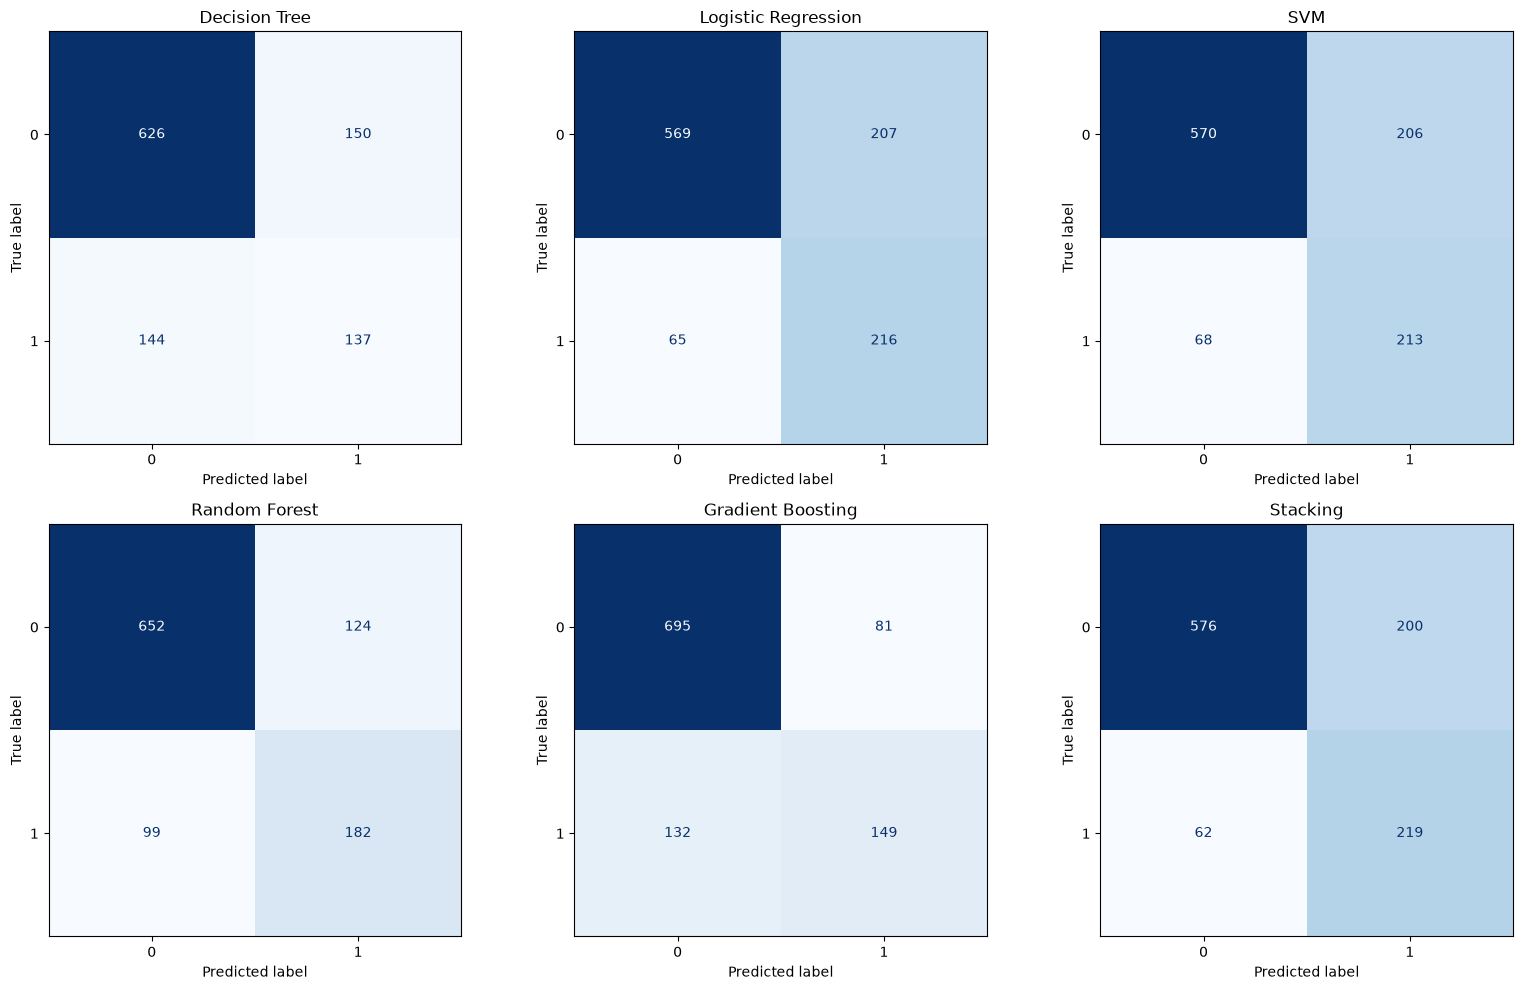

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_val_processed)

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

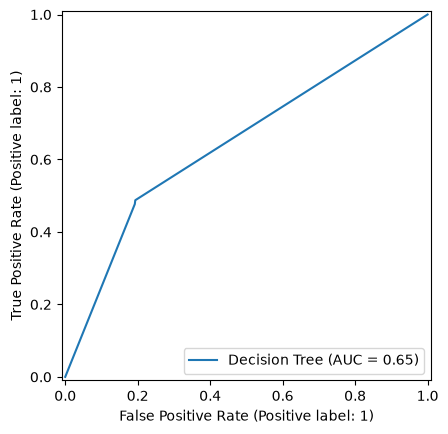

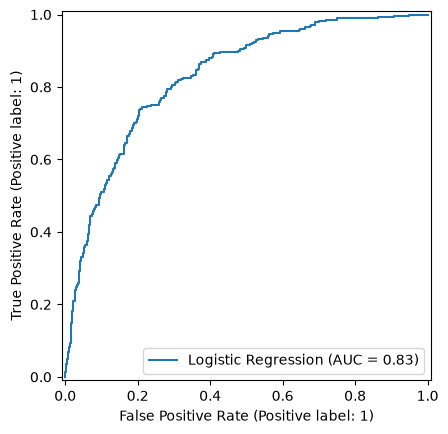

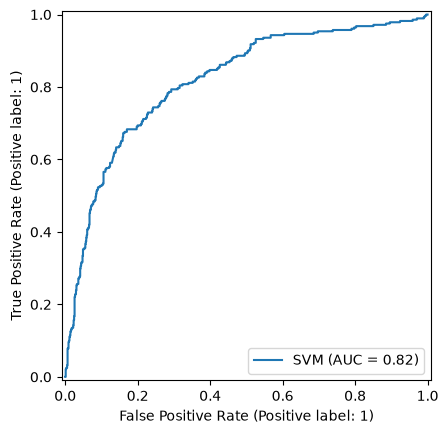

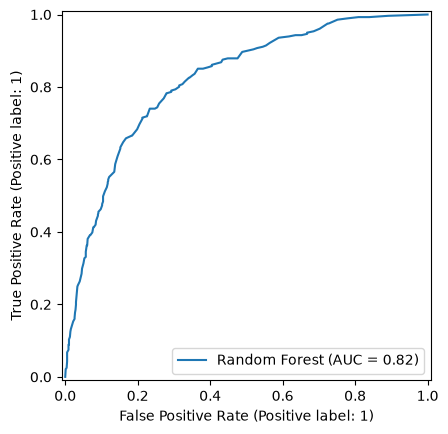

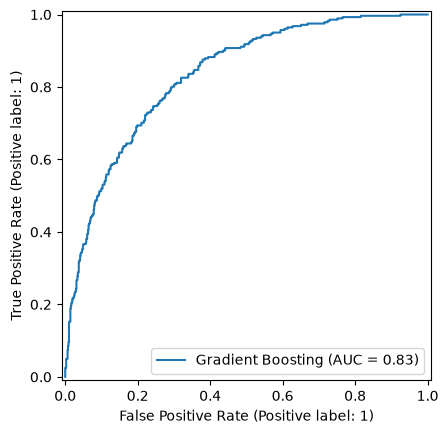

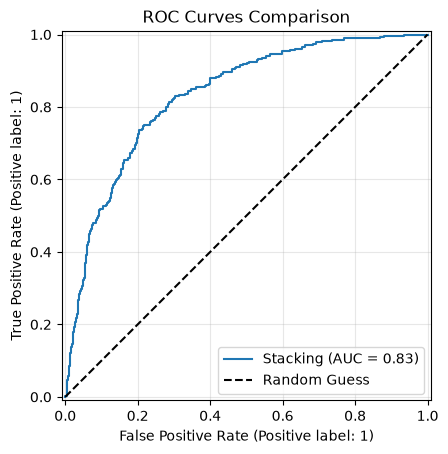

In [65]:
plt.figure(figsize=(10, 7))

for model_name, model in trained_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_val_processed,
        y_val,
        name=model_name
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves Comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [66]:
from statsmodels.stats.contingency_tables import mcnemar

best_model_name = comparison_df.iloc[0]["Model"]
second_model_name = comparison_df.iloc[1]["Model"]

best_pred = trained_models[best_model_name].predict(X_val_processed)
second_pred = trained_models[second_model_name].predict(X_val_processed)

both_correct = ((best_pred == y_val) & (second_pred == y_val)).sum()
best_correct_second_wrong = ((best_pred == y_val) & (second_pred != y_val)).sum()
best_wrong_second_correct = ((best_pred != y_val) & (second_pred == y_val)).sum()
both_wrong = ((best_pred != y_val) & (second_pred != y_val)).sum()

table = [
    [both_correct, best_correct_second_wrong],
    [best_wrong_second_correct, both_wrong]
]

test_result = mcnemar(table, exact=True)

print("Model 1:", best_model_name)
print("Model 2:", second_model_name)
print("McNemar statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)

if test_result.pvalue < 0.05:
    print("The difference is important statistically.")
else:
    print("The difference is not important statistically.")


Model 1: Stacking
Model 2: Random Forest
McNemar statistic: 55.0
p-value: 0.0017565589462647465
The difference is important statistically.


# E. Analysis & Interpretation

## Which Ensemble Method Was Best?

For this customer churn problem, **Stacking was the best overall model when we look at F1-score and Recall**. These two scores are important because we want to find customers who may leave.

- **Stacking:** F1 = **0.6257**, Recall = **0.7794**, ROC-AUC = **0.8317**
- **Random Forest:** F1 = **0.6201**, Recall = **0.6477**, ROC-AUC = **0.8184**
- **Gradient Boosting:** F1 = **0.5832**, Recall = **0.5302**, ROC-AUC = **0.8323**

Stacking had the highest F1-score and Recall. This means it found more customers who may leave while keeping a fair Precision score. It uses Logistic Regression, SVM, and Random Forest together. Then another Logistic Regression model uses their predictions to make the final decision.

Gradient Boosting had the highest Accuracy (**79.85%**) and Precision (**64.78%**). It also had a slightly higher ROC-AUC than Stacking. But its Recall (**53.02%**) and F1-score were lower. So it missed more customers who may leave.

Random Forest gave a good balance between score and training time. Its F1-score was close to Stacking, but it trained much faster.

For this **customer churn** problem, I selected **Stacking** as the best ensemble model because it had the best Recall and F1-score. If Accuracy or Precision is more important for the company, Gradient Boosting is also a good choice.


## Feature Importance

Feature importance shows which columns affect the prediction the most. I used Random Forest because it gives `feature_importances_` directly. The category columns were changed by one-hot encoding, so the feature names come from the preprocessing step.


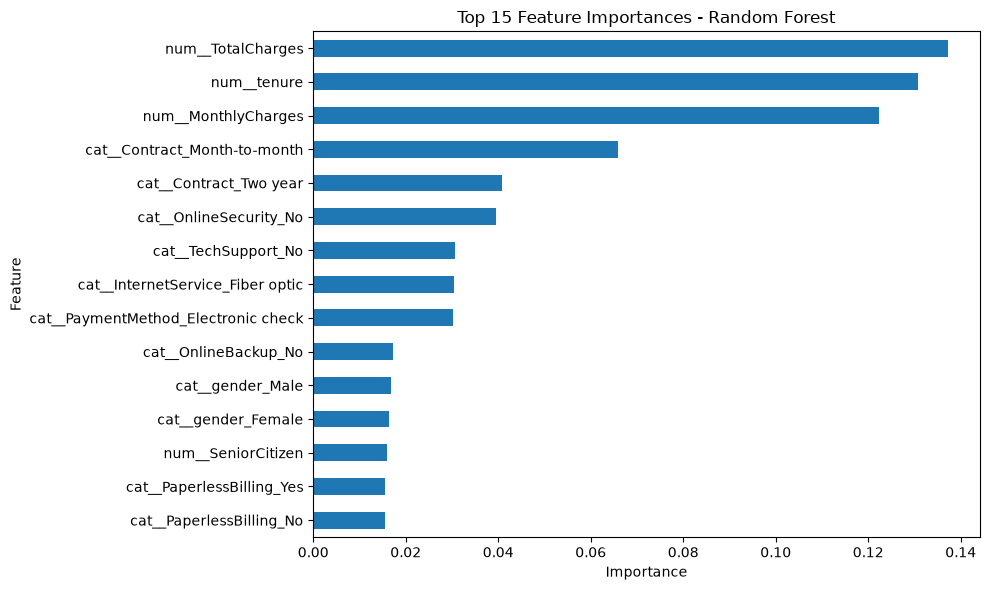

num__TotalCharges                      0.137300
num__tenure                            0.130664
num__MonthlyCharges                    0.122294
cat__Contract_Month-to-month           0.065818
cat__Contract_Two year                 0.040868
cat__OnlineSecurity_No                 0.039465
cat__TechSupport_No                    0.030680
cat__InternetService_Fiber optic       0.030337
cat__PaymentMethod_Electronic check    0.030186
cat__OnlineBackup_No                   0.017214
cat__gender_Male                       0.016887
cat__gender_Female                     0.016473
num__SeniorCitizen                     0.016017
cat__PaperlessBilling_Yes              0.015574
cat__PaperlessBilling_No               0.015516
dtype: float64

In [67]:
feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_features = rf_importance.head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_features


## Bias-Variance Tradeoff

- **Decision Tree:** one deep tree can learn the training data too much.
- **Random Forest:** it uses many trees, so it is usually more stable than one tree.
- **Gradient Boosting:** it improves the model step by step, but too many trees can cause overfitting.
- **Stacking:** it uses different models together. This can help when the models make different mistakes.

The Gradient Boosting learning curve shows this idea. Training accuracy keeps going up, but validation accuracy later stops improving and goes down. This can mean overfitting.


## Training Time and Performance

The comparison table shows training time with the model scores. This helps us see if a slower model gives a better result.

A more complex model is not always better. The chosen model should balance **F1/Recall**, other scores, and training time. For churn prediction, Recall is useful because missing a customer who may leave can cost the company money.


In [68]:
cost_summary = comparison_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Training Time (sec)"
]].copy()

cost_summary


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Stacking,0.752129,0.522673,0.779359,0.625714,0.831676,17.511889
1,Random Forest,0.789026,0.594771,0.647687,0.620102,0.818375,0.965013
2,Logistic Regression,0.742668,0.510638,0.768683,0.613636,0.829223,0.067396
3,SVM,0.740776,0.508353,0.758007,0.608571,0.817256,8.523146
4,Gradient Boosting,0.798486,0.647826,0.530249,0.583170,0.832261,20.659440
5,Decision Tree,0.721854,0.477352,0.487544,0.482394,0.646405,0.104904


# F. Final Test Evaluation

I used the validation set to compare the models and choose one model. I kept the test set separate until the end. This gives a fair final result.


In [69]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models_to_compare[best_model_name]

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_preprocessor = clone(preprocessor)
X_train_val_processed = final_preprocessor.fit_transform(X_train_val)
X_test_final_processed = final_preprocessor.transform(X_test)

final_model = clone(best_model)
final_model.fit(X_train_val_processed, y_train_val)

test_pred = final_model.predict(X_test_final_processed)
test_prob = final_model.predict_proba(X_test_final_processed)[:, 1]

final_test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Test Score": [
        accuracy_score(y_test, test_pred),
        precision_score(y_test, test_pred, zero_division=0),
        recall_score(y_test, test_pred, zero_division=0),
        f1_score(y_test, test_pred, zero_division=0),
        roc_auc_score(y_test, test_prob)
    ]
})

print("Selected model:", best_model_name)
final_test_results


Selected model: Stacking


,Metric,Test Score
0,Accuracy,0.751183
1,Precision,0.519274
2,Recall,0.817857
3,F1 Score,0.635229
4,ROC-AUC,0.849653


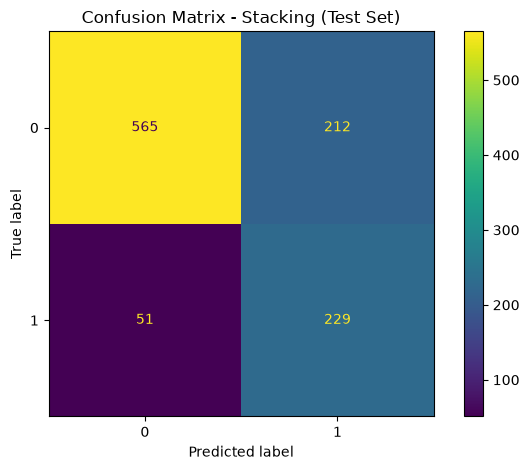

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred
)
plt.title(f"Confusion Matrix - {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()


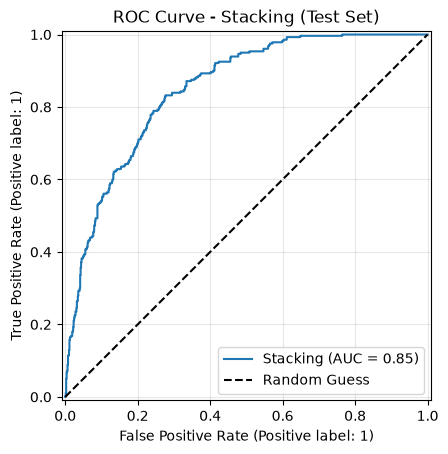

In [71]:
RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    name=best_model_name
)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve - {best_model_name} (Test Set)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Predict Churn for a New Customer

We can enter a new customer's information and use the trained model to predict whether the customer is likely to churn.

In [72]:
# Create data for a new customer

new_customer = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [10],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.50],
    "TotalCharges": [850.00]
})

# Apply the same preprocessing used during training
new_customer_processed = final_preprocessor.transform(new_customer)

# Make prediction
new_prediction = final_model.predict(new_customer_processed)

# Get prediction probability
new_probability = final_model.predict_proba(new_customer_processed)[:, 1]

# Display the prediction
if new_prediction[0] == 1:
    print("Predicted Churn: Yes")
else:
    print("Predicted Churn: No")

print("Churn Probability:", round(new_probability[0] * 100, 2), "%")


Predicted Churn: Yes
Churn Probability: 88.99 %
